# BNP Paribas Finanzas Personales - Detección de Fraude en Canastas

### Resumen

El fraude es un problema importante tanto para los comerciantes como para los clientes. En 2024, 45% de las empresas en México indican haber sufrido el intento o la materialización de un fraude de acuerdo con el estudio Impacto de los delitos financieros en México 2024 perdiendo entre 10 y 13 millones de pesos anualmente debido a actividades fraudulentas. Según estudios de la AMVO realizados entre 2020 y 2021 con más de 1800 participantes dónde se les pregunto si habían sido víctimas de fraude electrónico durante el último año se encontró que el 37% tuvo pagos no reconocidos en su tarjeta, un 22% cargos duplicados, mientras que un 20% fue víctima de clonación. Durante las temporadas de mayor actividad para el sector retail, los fraudes en comercio electrónico se incrementan en México impulsados por ataques más automatizados, identidades falsas y el uso de deepfakes haciendo que el comportamiento parezca legítimo.

En este notebook se explora el dataset proporcionado por [URL](https://challengedata.ens.fr/challenges/104) el objetivo es processar y analizar la canasta de compras para la detección de compras fraudulentas.

### Conjunto de Datos

Cada linea del dataset representa una compra y las columnas representan los productos incluidos en esa compra de un total de 2456 columnas de las cuales las últimas 7 son:

 - Numero de items
 - Numero total de items
 - Costo de total
 - Costo medio de items
 - Costo máximo de items
 - Costo mínimo de items
 - Bandera de Fraude

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from skopt import BayesSearchCV

## Entendimiento del problema y de los datos

Leemos el archivo usando la funcion `read_csv` de pandas y el parametro `index_col` lo asignamos a la columna `ID`

In [2]:
df = pd.read_csv("../data/fraud/FraudeCanastas.csv", index_col="ID")

df.head()

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag
ID,,,,,,,,,,,,,,,,,,,,,
130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1299,649.500000,1299,0.0,1.0
195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3,3,4119,1373.000000,2470,0.0,1.0
217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,2806,1403.000000,2799,7.0,1.0
552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1206,603.000000,1199,7.0,1.0
854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,19,27,1807,66.925926,195,4.0,1.0


In [3]:
# Get dataset info
df.info()

<class 'pandas.DataFrame'>
Index: 9319 entries, 130 to 49022
Columns: 2456 entries, APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90 to fraud_flag
dtypes: float64(2452), int64(4)
memory usage: 174.7 MB


In [4]:
# describes the dataset
def describe(df):
    unique = []
    for col in df.columns:
        unique.append(df[col].unique())
    unique_series = pd.Series(unique, index=df.columns)
    return pd.concat(
        [
            df.dtypes,
            df.isna().sum(),
            round(df.isna().sum() / len(df) * 100, 1),
            df.nunique(),
            unique_series,
        ],
        axis=1,
        keys=["dtype", "missing", "%null", "nunique", "unique"],
    )


describe(df)

,dtype,missing,%null,nunique,unique
APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,float64,0,0.0,2,"[0.0, 1000.0]"
AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,float64,0,0.0,2,"[0.0, 20.0]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,float64,0,0.0,8,"[0.0, 125.0, 119.0, 120.0, 500.0, 129.0, 109.0..."
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,float64,0,0.0,8,"[0.0, 109.0, 100.0, 105.0, 104.0, 99.0, 119.0,..."
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,float64,0,0.0,4,"[0.0, 149.0, 158.0, 168.0]"
...,...,...,...,...,...
costo_total,int64,0,0.0,1639,"[1299, 4119, 2806, 1206, 1807, 1263, 942, 1199..."
costo_medio_item,float64,0,0.0,2034,"[649.5, 1373.0, 1403.0, 603.0, 66.925925925925..."
costo_item_max,int64,0,0.0,540,"[1299, 2470, 2799, 1199, 195, 280, 938, 929, 1..."
costo_item_min,float64,0,0.0,528,"[0.0, 7.0, 4.0, 1249.0, 25.0, 2470.0, 999.0, 1..."


Creamos la gráfica boxplot para las variables `Nb_of_items`, `total_of_items`, `costo_total`, `costo_medio_item`, `costo_medio_max`, `costo_medio_min` agrupadas for la variable `fraud_flag`

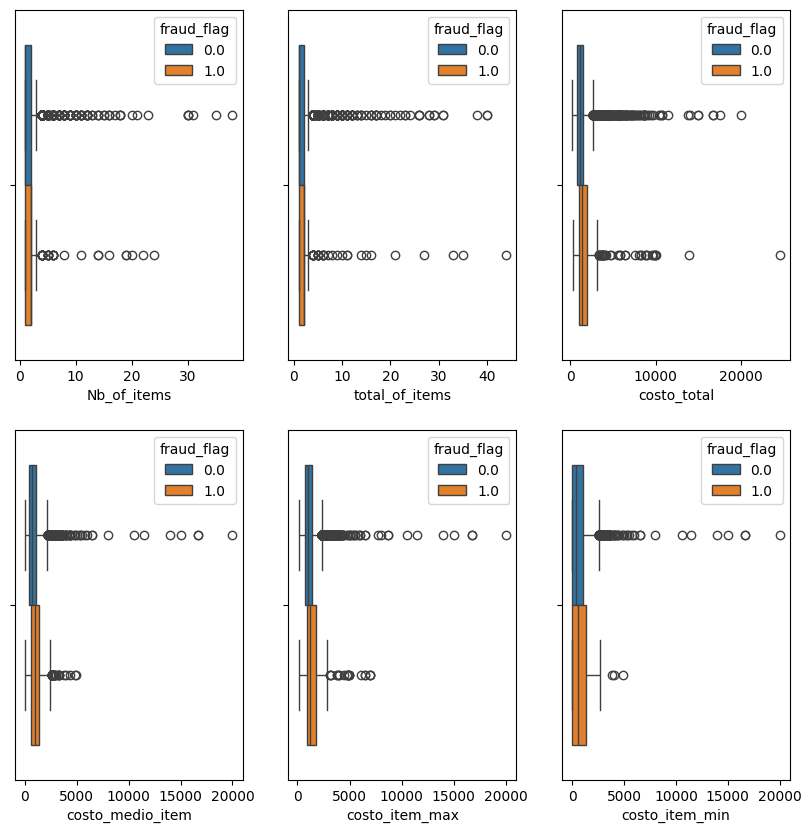

In [5]:
fig, axs = plt.subplots(2, 3, figsize=(10, 10))
axs = axs.flatten()

for i, c in enumerate(
    [
        "Nb_of_items",
        "total_of_items",
        "costo_total",
        "costo_medio_item",
        "costo_item_max",
        "costo_item_min",
    ]
):
    sns.boxplot(
        df.iloc[:, -7:],
        x=c,
        hue="fraud_flag",
        ax=axs[i],
    )

_ = plt.show()

In [6]:
# Create a sparse matrix
sparse_matrix = csr_matrix(df.iloc[:, :-7].values)
# retrieve the rows and cols that have a cell different from zero
rows, cols = sparse_matrix.nonzero()
# retrieve the value cells
values = sparse_matrix.data

Creamos una gráfica para de puntos hexagonales de indice de la columna de producto por el precio del producto y en el eje z se muestra si fue legítima la compra o fraude.

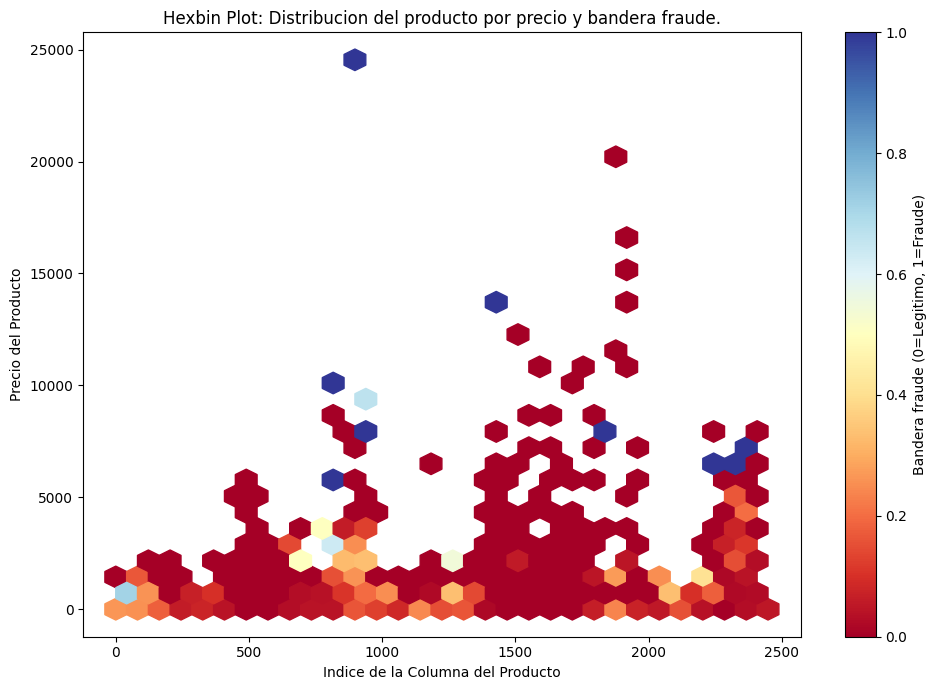

In [ ]:
# Create hexbin plot from sparse matrix data
fig, ax = plt.subplots(figsize=(10, 7))

# Get fraud flags for each row
fraud_flags = df.iloc[rows, -1].to_list()  # type: ignore

# Create hexbin plot
hexbin = plt.hexbin(
    cols,
    values,
    C=fraud_flags,
    gridsize=30,
    cmap="RdYlBu",
    mincnt=1,
)

ax.set_xlabel("Indice de la Columna del Producto")
ax.set_ylabel("Precio del Producto")
ax.set_title("Hexbin Plot: Distribucion del producto por precio y bandera fraude.")

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label("Bandera fraude (0=Legitimo, 1=Fraude)")

plt.tight_layout()
plt.show()

## Preprocesamiento de Datos

In [8]:
items = df.iloc[:, :-1]
target = df.iloc[:, -1]

In [ ]:
scaler = StandardScaler()
items_scaled = scaler.fit_transform(items)
items_scaled_df = pd.DataFrame(
    items_scaled,
    index=df.index,
    columns=scaler.get_feature_names_out(),
)

describe(items_scaled_df)

,dtype,missing,%null,nunique,unique
APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,float64,0,0.0,2,"[-0.010359496474407552, 96.52978814852958]"
AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,float64,0,0.0,2,"[-0.010359496474407552, 96.52978814852958]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,float64,0,0.0,8,"[-0.04013544941804104, 16.393179714322052, 15...."
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,float64,0,0.0,8,"[-0.03383755034725062, 17.73824226029241, 16.2..."
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,float64,0,0.0,4,"[-0.01792357802650007, 52.37669478137174, 55.5..."
...,...,...,...,...,...
total_of_items,float64,0,0.0,34,"[0.07447036629687828, 0.5947022579914873, 13.0..."
costo_total,float64,0,0.0,1639,"[-0.03624437764912085, 2.5979405404488234, 1.3..."
costo_medio_item,float64,0,0.0,2034,"[-0.3388901227312699, 0.6462865014209213, 0.68..."
costo_item_max,float64,0,0.0,540,"[0.14559234249482972, 1.6337106621434885, 2.05..."


## Dataset split

Dataset is splitted train and test with a percentage of 80% and 20% of the total records respectively

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    items_scaled_df,
    target,
    test_size=0.20,
    shuffle=True,
    random_state=42,
    stratify=target,
)

len(X_train), len(X_test), len(y_train), len(y_test)

(7455, 1864, 7455, 1864)

## Class weight

Since we are dealing with a unbalanced dataset we must estimate the weights of each class this is done with the following formula.

$$
weights = \frac{N}{classes * freq}
$$

 - N is the number of samples
 - classes are the number of classes
 - freq is the bincount or frequency of class i

In [11]:
class_weights = compute_class_weight(
    y=target, class_weight="balanced", classes=np.unique(y_train)
)

np.unique(y_train), class_weights

(array([0., 1.]), array([0.5824375 , 3.53260045]))

## Logistic Regression

The parameters that were tuned are `C` and `l1_ratio`.

In [18]:
from skopt.space import Real

params = {
    "C": Real(1e-3, 1e3),
    "l1_ratio": Real(0.0, 1.0),
}

bayes_log_regression = BayesSearchCV(
    LogisticRegression(
        class_weight={0: 0.5824375, 1: 3.53260045},
        solver="saga",
        max_iter=1500,
        tol=0.01,
    ),
    params,
    n_iter=50,
    scoring="accuracy",
    verbose=1,
)

bayes_log_regression.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,"LogisticRegre...ga', tol=0.01)"
,search_spaces,"{'C': Real(low=0.00...m='normalize'), 'l1_ratio': Real(low=0.0,...m='normalize')}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'accuracy'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,None


In [19]:
print(f"Best Params: {bayes_log_regression.best_params_}")  # type: ignore

Best Params: OrderedDict({'C': 0.001, 'l1_ratio': 0.17780399608378006})


In [20]:
print(f"Score: {bayes_log_regression.score(X_train, y_train)}")
y_pred = bayes_log_regression.predict(X_train)
print(classification_report(y_train, y_pred))

Score: 0.7362843729040912
              precision    recall  f1-score   support

         0.0       0.93      0.75      0.83      6400
         1.0       0.31      0.68      0.42      1055

    accuracy                           0.74      7455
   macro avg       0.62      0.71      0.62      7455
weighted avg       0.84      0.74      0.77      7455



In [21]:
print(f"Score: {bayes_log_regression.score(X_test, y_test)}")
y_pred = bayes_log_regression.predict(X_test)
print(classification_report(y_test, y_pred))

Score: 0.7199570815450643
              precision    recall  f1-score   support

         0.0       0.93      0.73      0.82      1600
         1.0       0.28      0.64      0.39       264

    accuracy                           0.72      1864
   macro avg       0.61      0.69      0.61      1864
weighted avg       0.83      0.72      0.76      1864



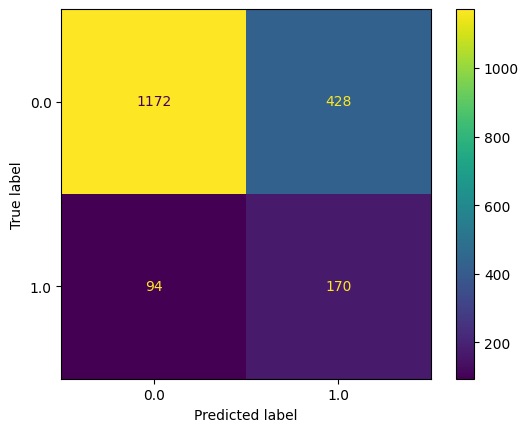

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=np.unique(y_train))

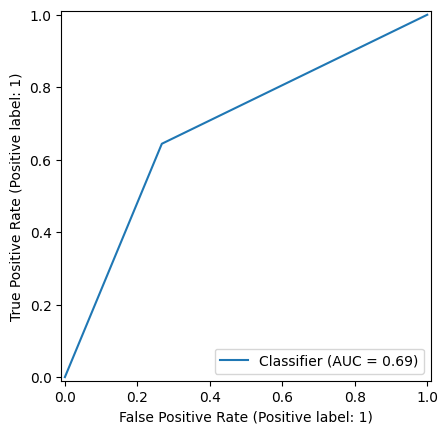

In [23]:
RocCurveDisplay.from_predictions(y_test, y_pred)

## Random Forest

The parameters that were tuned are `n_estimators`, `max_depth`, `min_samples_leaf`, `min_samples_split` and `max_leaf_nodes`

In [24]:
from skopt.space import Integer

params = {
    "n_estimators": Integer(1, 500),
    "max_depth": Integer(1, 2500),
    "min_samples_leaf": Integer(1, 20),
    "min_samples_split": Integer(2, 20),
    "max_leaf_nodes": Integer(2, 500),
}

bayes_tree = BayesSearchCV(
    RandomForestClassifier(
        criterion="entropy",
        class_weight={0: 0.5824375, 1: 3.53260045},
        n_jobs=-1,
    ),
    params,
    n_iter=50,
    scoring="accuracy",
    verbose=1,
)

bayes_tree.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,"RandomForestC...y', n_jobs=-1)"
,search_spaces,"{'max_depth': Integer(low=1...m='normalize'), 'max_leaf_nodes': Integer(low=2...m='normalize'), 'min_samples_leaf': Integer(low=1...m='normalize'), 'min_samples_split': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'accuracy'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,None


In [25]:
print(f"Best Params: {bayes_tree.best_params_}")  # type: ignore

Best Params: OrderedDict({'max_depth': 2373, 'max_leaf_nodes': 270, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 454})


In [26]:
print(f"Score: {bayes_tree.score(X_train, y_train)}")
y_pred = bayes_tree.predict(X_train)
print(classification_report(y_train, y_pred))

Score: 0.8637156270959088
              precision    recall  f1-score   support

         0.0       0.96      0.87      0.92      6400
         1.0       0.51      0.80      0.62      1055

    accuracy                           0.86      7455
   macro avg       0.74      0.84      0.77      7455
weighted avg       0.90      0.86      0.88      7455



In [27]:
print(f"Score: {bayes_tree.score(X_test, y_test)}")
y_pred = bayes_tree.predict(X_test)
print(classification_report(y_test, y_pred))

Score: 0.8261802575107297
              precision    recall  f1-score   support

         0.0       0.93      0.86      0.90      1600
         1.0       0.42      0.60      0.49       264

    accuracy                           0.83      1864
   macro avg       0.67      0.73      0.69      1864
weighted avg       0.86      0.83      0.84      1864



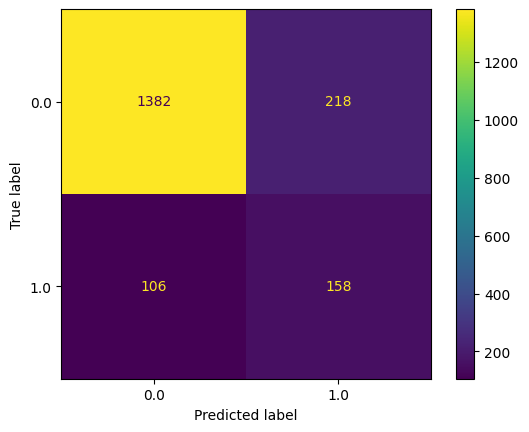

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=np.unique(y_train))

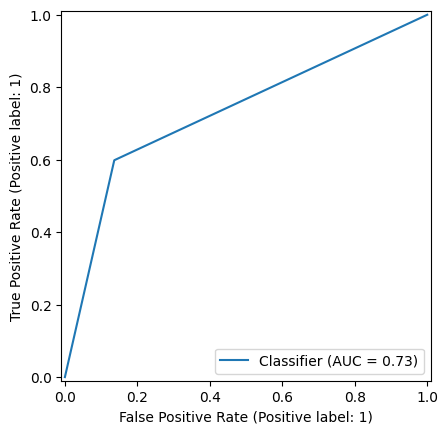

In [29]:
RocCurveDisplay.from_predictions(y_test, y_pred)

## Conclusión

| Model               | Class | Precision | Recall | F1-score | Accuracy |
|---------------------|-------|-----------|--------|----------|----------|
| Logistic Regression | 0.0   | 0.93      | 0.73   | 0.82     | 0.72     |
| Logistic Regression | 1.0   | 0.28      | 0.64   | 0.39     | 0.72     |
| Random Forest       | 0.0   | 0.93      | 0.86   | 0.90     | 0.83     |
| Random Forest       | 1.0   | 0.42      | 0.60   | 0.49     | 0.83     |


### Resultados

 - El **Random Forest** es el modelo seleccionado porque logra el mejor equilibrio en todas las métricas para la clase de fraude: mayor precisión, recall competitivo, mejor puntuación F1 y mayor precisión general.
 - En el dominio del fraude, el costo de no detectar un fraude verdadero es mayor que otros errores. Sin embargo, la brecha de recall entre Logistic Regression y Random Forest es solo de 4 puntos, mientras que Random Forest gana 14 puntos en precisión, lo que lo hace más viable operativamente.
 - Logistic Regression sería una segunda selección si el negocio prioriza el máximo recall y tiene capacidad para revisar manualmente un alto volumen de falsos positivos.